In [3]:
import pandas as pd
import numpy as np
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [4]:
california = fetch_california_housing(as_frame=True)
data = california.frame

In [5]:
print(data.head())

   MedInc  HouseAge  AveRooms  AveBedrms  Population  AveOccup  Latitude  \
0  8.3252      41.0  6.984127   1.023810       322.0  2.555556     37.88   
1  8.3014      21.0  6.238137   0.971880      2401.0  2.109842     37.86   
2  7.2574      52.0  8.288136   1.073446       496.0  2.802260     37.85   
3  5.6431      52.0  5.817352   1.073059       558.0  2.547945     37.85   
4  3.8462      52.0  6.281853   1.081081       565.0  2.181467     37.85   

   Longitude  MedHouseVal  
0    -122.23        4.526  
1    -122.22        3.585  
2    -122.24        3.521  
3    -122.25        3.413  
4    -122.25        3.422  


In [6]:
x = data.drop("MedHouseVal", axis = 1)
y = data["MedHouseVal"]

In [7]:
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.2, random_state = 42)


In [8]:
model = LinearRegression()
model.fit(x_train, y_train)

LinearRegression()

In [22]:
from sklearn.metrics import mean_squared_error, r2_score
y_pred = model.predict(x_test)

In [26]:
print("\nEnter the house details below:")
MedInc = float(input("Median Income (in $10,000s): "))
HouseAge = float(input("Median House Age: "))
AveRooms = float(input("Average Rooms per household: "))
AveBedrms = float(input("Average Bedrooms per household: "))
Population = float(input("Population of the area: "))
AveOccup = float(input("Average Occupants per household: "))
Latitude = float(input("Latitude : "))
Longitude = float(input("Longitude : "))

user_data = pd.DataFrame([{
    "MedInc": MedInc,
    "HouseAge": HouseAge,
    "AveRooms": AveRooms,
    "AveBedrms": AveBedrms,
    "Population": Population,
    "AveOccup": AveOccup,
    "Latitude": Latitude,
    "Longitude": Longitude
}])

pred_units = model.predict(user_data)[0]     
pred_usd = pred_units * 100000               

print(f"\nPredicted Median House Value: {pred_units:.3f} (in $100k units)")
print(f"Approx. Price: ${pred_usd:,.2f}")





Enter the house details below:


Median Income (in $10,000s):  6.0
Median House Age:  20
Average Rooms per household:  5.5
Average Bedrooms per household:  1.0
Population of the area:  500
Average Occupants per household:  3.0
Latitude :  34.05
Longitude :  -118.25



Predicted Median House Value: 2.949 (in $100k units)
Approx. Price: $294,857.42


In [27]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
print("Model Performance")
print(f" RMSE {rmse:.3f} (=${rmse*100000:,.0f})")
print(f" R^2 Score : {r2:.3f}")

Model Performance
 RMSE 0.746 (=$74,558)
 R^2 Score : 0.576


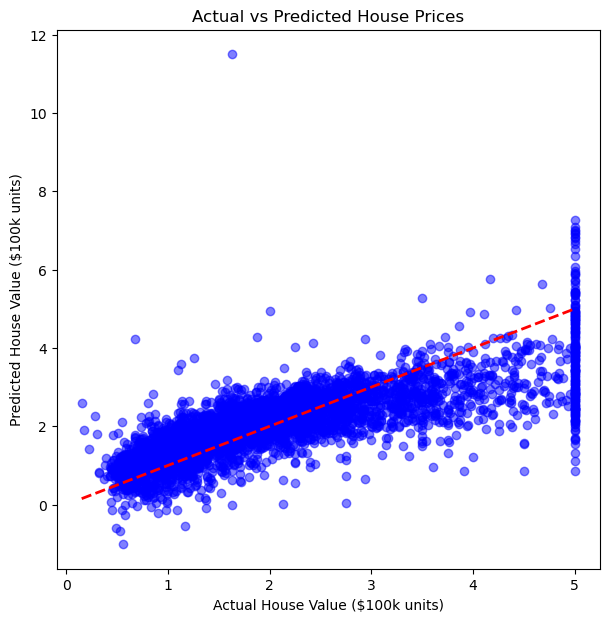

In [28]:
import matplotlib.pyplot as plt
plt.figure(figsize=(7,7))
plt.scatter(y_test, y_pred, alpha=0.5, color="blue")
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         "r--", lw=2)  

plt.xlabel("Actual House Value ($100k units)")
plt.ylabel("Predicted House Value ($100k units)")
plt.title("Actual vs Predicted House Prices")
plt.show()
